<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Paso 4

In [60]:
# Cargo el URL y convierto la tabla a DataFrame por si se requiere.

url = 'https://practicum-content.s3.us-west-1.amazonaws.com/data-analyst-eng/moved_chicago_weather_2017.html'
df = pd.read_html(requests.get(url).content)[0] # Selecciono la tabla [0] para que no sea una lista.
df

,Date and time,Temperature,Description
0,2017-11-01 00:00:00,276.15,broken clouds
1,2017-11-01 01:00:00,275.70,scattered clouds
2,2017-11-01 02:00:00,275.61,overcast clouds
3,2017-11-01 03:00:00,275.35,broken clouds
4,2017-11-01 04:00:00,275.24,broken clouds
...,...,...,...
692,2017-11-29 20:00:00,281.34,few clouds
693,2017-11-29 21:00:00,281.69,sky is clear
694,2017-11-29 22:00:00,281.07,few clouds
695,2017-11-29 23:00:00,280.06,sky is clear


## Exploración

In [61]:
file1 = pd.read_csv('/datasets/project_sql_result_01.csv')
print(file1.info(),'\n')
print(file1.describe(),'\n')
print('Número de empresas = ', file1['company_name'].nunique(),'\n')
file1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None 

       trips_amount
count     64.000000
mean    2145.484375
std     3812.310186
min        2.000000
25%       20.750000
50%      178.500000
75%     2106.500000
max    19558.000000 

Número de empresas =  64 



,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


In [62]:
file2 = pd.read_csv('/datasets/project_sql_result_04.csv')
print(file2.info(),'\n')
print(file2.describe(),'\n')
print('Número de ubicaciones = ', file2['dropoff_location_name'].nunique(),'\n')
file2.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None 

       average_trips
count      94.000000
mean      599.953728
std      1714.591098
min         1.800000
25%        14.266667
50%        52.016667
75%       298.858333
max     10727.466667 

Número de ubicaciones =  94 



,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


In [63]:
file3 = pd.read_csv('/datasets/project_sql_result_07.csv')
print(file3.info(),'\n')
print(file3.describe(),'\n')
print('Número de categorías de clima = ', file3['weather_conditions'].nunique())

# Cambio la columna de fecha y hora a tipo datetime.
file3['start_ts'] = pd.to_datetime(file3['start_ts'], format='%Y-%m-%d %H:%M:%S')

# La condición del clima debería de ser de tipo categoría y no objeto.
file3['weather_conditions'] = file3['weather_conditions'].astype('category')
print(file3.dtypes,'\n')
file3.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
None 

       duration_seconds
count       1068.000000
mean        2071.731273
std          769.461125
min            0.000000
25%         1438.250000
50%         1980.000000
75%         2580.000000
max         7440.000000 

Número de categorías de clima =  2
start_ts              datetime64[ns]
weather_conditions          category
duration_seconds             float64
dtype: object 



,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


## Análisis

- 10 Principales barrios en términos de finalización del recorrido.
- Gráficos:
    - Empresas y número de viajes.
    - 10 Barrios por número de finalizaciones.

### Empresas y Viajes

In [64]:
# Veo cuántas empresas diferentes hay y visualizo sus viajes en un histograma.
print(f"Número de empresas = {file1['company_name'].nunique()}")
file1['comptrip_ratio'] = file1['trips_amount']/file1['trips_amount'].sum()*100
file1_sorted = file1.sort_values(by='comptrip_ratio', ascending = False)
file1_sorted

Número de empresas = 64


,company_name,trips_amount,comptrip_ratio
0,Flash Cab,19558,14.243578
1,Taxi Affiliation Services,11422,8.318343
2,Medallion Leasing,10367,7.550014
3,Yellow Cab,9888,7.201171
4,Taxi Affiliation Service Yellow,9299,6.772218
...,...,...,...
59,4053 - 40193 Adwar H. Nikola,7,0.005098
60,2733 - 74600 Benny Jona,7,0.005098
61,5874 - 73628 Sergey Cab Corp.,5,0.003641
62,2241 - 44667 - Felman Corp,3,0.002185


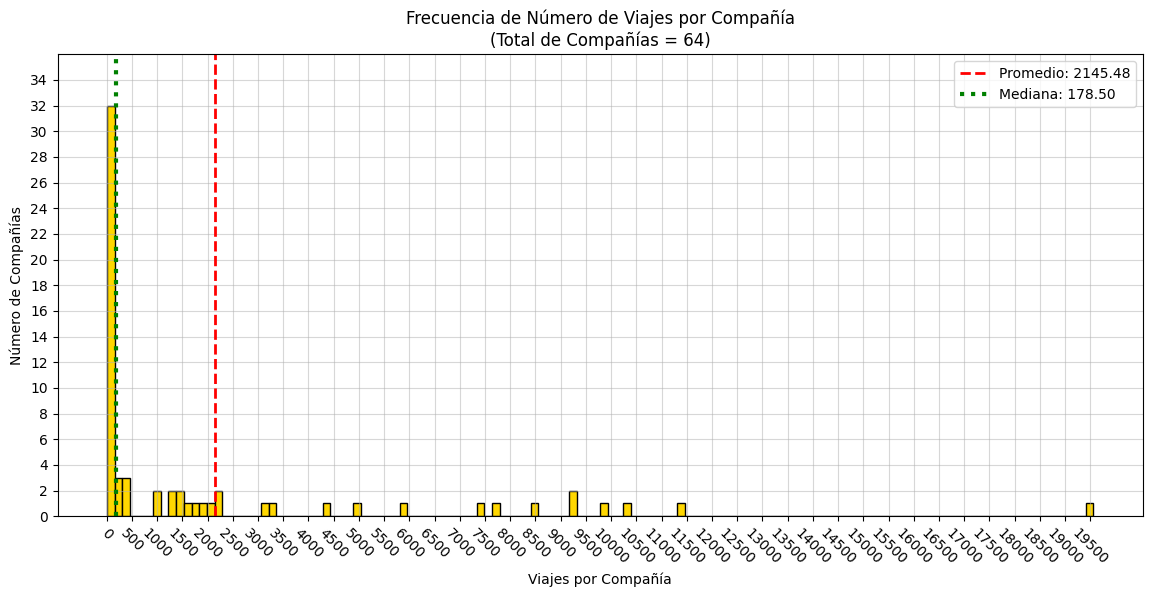

In [65]:
import matplotlib.pyplot as plt
import numpy as np

file1_sorted_mean = np.nanmean(file1_sorted['trips_amount'])
file1_sorted_median = np.nanmedian(file1_sorted['trips_amount'])

plt.figure(figsize=(14, 6))
plt.title(f'''Frecuencia de Número de Viajes por Compañía
(Total de Compañías = {file1_sorted["company_name"].count()})''')
plt.hist(
    file1_sorted['trips_amount'],
    bins = 128,
    edgecolor = '0',
    color = 'gold'
)
plt.axvline(file1_sorted_mean, color='red', linestyle='--', linewidth=2, label=f'Promedio: {file1_sorted_mean:.2f}')
plt.axvline(file1_sorted_median, color='green', linestyle=':', linewidth=3, label=f'Mediana: {file1_sorted_median:.2f}')
plt.xticks(np.arange(0, 20000, 500), rotation=-45)
plt.yticks(np.arange(0, 36, 2))
plt.ylim(0, 36)
plt.xlabel('Viajes por Compañía')
plt.ylabel('Número de Compañías')
plt.legend(loc='upper right')
plt.grid(alpha = 0.5)
plt.show()

- La mayoría de las empresas (38 de 64) hace menos de 500 viajes.
    - Hay una sola empresa que tiene muchos más viajes que todas:  Flash Cab, con el 14.24 % de todos los viajes.
    - Salvo por esa empresa, el resto no pasa de 11,500 viajes. Evidentemente Flash Cab domina el mercado.

### 10 Barrios con más viajes

In [66]:
# Creo una columna del porcentaje del mercado por destino.
# Veo las 10 ubicaciones con más mercado.
file2['loctrip_ratio'] = file2['average_trips'] / file2['average_trips'].sum()*100
file2_sorted = file2.sort_values(by='loctrip_ratio', ascending = False)
file2_sorted.head(10)

,dropoff_location_name,average_trips,loctrip_ratio
0,Loop,10727.466667,19.021798
1,River North,9523.666667,16.887236
2,Streeterville,6664.666667,11.817696
3,West Loop,5163.666667,9.156143
4,O'Hare,2546.900000,4.516128
5,Lake View,2420.966667,4.292825
6,Grant Park,2068.533333,3.667895
7,Museum Campus,1510.000000,2.677511
8,Gold Coast,1364.233333,2.419040
9,Sheffield & DePaul,1259.766667,2.233801


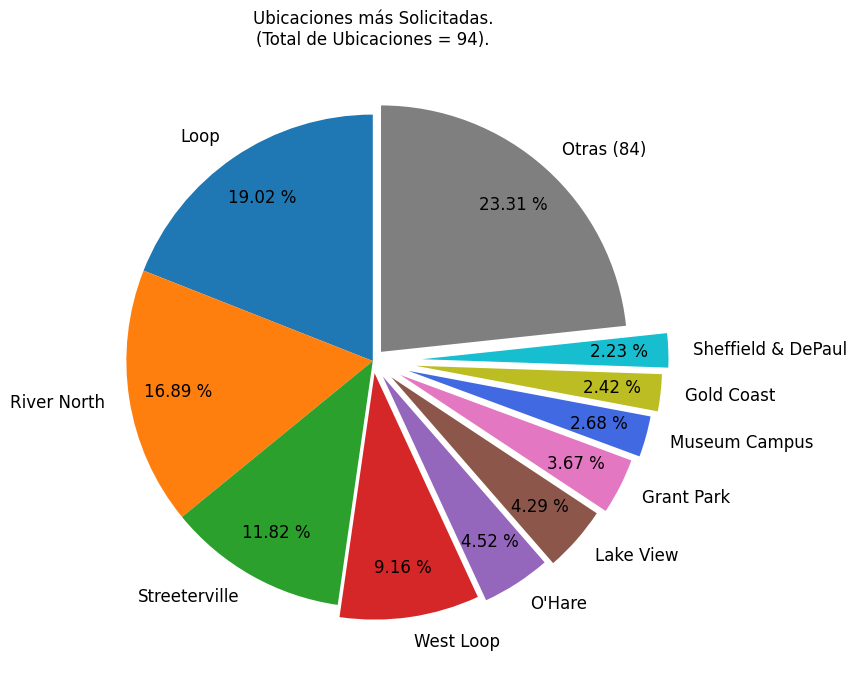

In [67]:
# Hago una gráfica especificando el mercado de las 10 destinos con más mercado.
labels = [loc for loc in file2_sorted['dropoff_location_name'].head(10)]
labels.append(f'Otras ({file2_sorted["dropoff_location_name"].count()-10})')
values = [val for val in file2_sorted['average_trips'].head(10)]
values.append(file2_sorted['average_trips'].iloc[10:].sum())
colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown','tab:pink','royalblue','tab:olive','tab:cyan','tab:gray'] 
explode = (0,0,0,0.05,0.075,0.1,0.125,0.15,0.175,0.2,0.05)

plt.figure(figsize=(8, 8))
plt.title(f'''Ubicaciones más Solicitadas.
(Total de Ubicaciones = {file2_sorted["dropoff_location_name"].count()}).''')
plt.pie(values,
        labels = labels,
        autopct = '%.2f %%',
        pctdistance = 0.8,
        explode = explode,
        textprops = {'fontsize': 12},
        labeldistance=1.1,
        startangle=90,
        colors = colors
       )
plt.show()

- Podemos apreciar que las ubicaciones: Loop, River North, Streeterville, y West Loop tienen más del 50% del mercado de taxis.
    - 19.02 % = Loop.
    - 16.89 % = River North.
    - 11.82 % = Streeterville.
    - 09.16 % West Loop.

### Conclusiones

- El mercado, a pesar de tener mucha competencia, tiene preferencias evidentes tanto en las empresas de taxi como en los destinos de viaje.
    - En cuanto a empresas, las 3 preferidas son Flash Cab, Taxi Affiliation Services, y Medallion Leasing.
        - Las 3 empresas mencionadas tienen 14.24 %, 8.32 %, y 7.55% del mercado respectivamente, sumando un poco más del 30%.
        - Estas 3 empresas dominan significativamente, ya que lo esperado es que cada una tenga 1.56 %, sumando 4.69 % entre las 3.
    - Las 3 ubicaciones más populares son Loop, River North, y Streeterville.
        - Estos 3 destinos son visitados por 19.02 %, 16.89 %, y 11.82 % de los clientes respectivamente, sumando casi la mitad de todos los viajes con 47.73 % del total.

- Tomando en cuenta lo anterior, y asumiendo que las empresas operan con la misma capacidad de oferta, y que ofrecen viajes a todos los destinos, se podría concluir que la ventaja competitiva es evidente. La cuestión está en que, si lo que se asume es falso, más información podría revelar el porqué de estas diferencias tan pronunciadas.
    - Por ejemplo, es posible que la ventaja existe solamente porque las empresas más grandes son las únicas que ofrecen viajes a los destinos más populares, pero esto ya es especulación.

# Paso 5

In [87]:
# Viajes desde Loop hasta Aeropuerto O'Hare.
# Hago una columna que indique el día de la semana para corroborar que todos sean sábado
#y la hago tipo categoría.

file3['dow'] = file3['start_ts'].dt.day_name()
file3['dow'] = file3['dow'].astype('category')

print(f'Días de la semana únicos de los viajes: {file3["dow"].unique()}', '\n')
file3

Días de la semana únicos de los viajes: ['Saturday']
Categories (1, object): ['Saturday'] 



,start_ts,weather_conditions,duration_seconds,dow
0,2017-11-25 16:00:00,Good,2410.0,Saturday
1,2017-11-25 14:00:00,Good,1920.0,Saturday
2,2017-11-25 12:00:00,Good,1543.0,Saturday
3,2017-11-04 10:00:00,Good,2512.0,Saturday
4,2017-11-11 07:00:00,Good,1440.0,Saturday
...,...,...,...,...
1063,2017-11-25 11:00:00,Good,0.0,Saturday
1064,2017-11-11 10:00:00,Good,1318.0,Saturday
1065,2017-11-11 13:00:00,Good,2100.0,Saturday
1066,2017-11-11 08:00:00,Good,1380.0,Saturday


## Hipótesis

"La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos".
- h0 = La duración promedio de viajes en días lluviosos y no lluviosos son iguales los sábado.
- h1 = La duración promedio de viajes en días lluviosos y no lluviosos no son iguales los sábado.

Se eligieron estas hipótesis nula y alternativa para corroborar si los valores promedio de la duración de los días lluviosos y no lluviosos están dentro de 3 desviaciones estandar o no.

Se debe de hacer una prueba de 2 colas porque podría haber una diferencia positiva o negativa en la duración.

Utilizaré un alpha de 5.00 % como es común en este tipo de pruebas estadísticas.

### Prueba de Hipótesis

In [100]:
# Divido los datos en días buenos y malos para poder comparar sus medidas de tendencia central.

dfbuenos = file3[file3['weather_conditions'] == 'Good']
dfmalos = file3[file3['weather_conditions'] == 'Bad']

print(df_buenos.head(), '\n\n', df_malos.head())

             start_ts weather_conditions  duration_seconds       dow
0 2017-11-25 16:00:00               Good            2410.0  Saturday
1 2017-11-25 14:00:00               Good            1920.0  Saturday
2 2017-11-25 12:00:00               Good            1543.0  Saturday
3 2017-11-04 10:00:00               Good            2512.0  Saturday
4 2017-11-11 07:00:00               Good            1440.0  Saturday 

               start_ts weather_conditions  duration_seconds       dow
6  2017-11-04 16:00:00                Bad            2969.0  Saturday
30 2017-11-18 12:00:00                Bad            1980.0  Saturday
34 2017-11-04 17:00:00                Bad            2460.0  Saturday
51 2017-11-04 16:00:00                Bad            2760.0  Saturday
52 2017-11-18 12:00:00                Bad            2460.0  Saturday


In [110]:
# Medidas de tendencia central de cada tabla.
# Almacenaré los valores en variables por practicidad.
promediob = round(dfbuenos['duration_seconds'].mean(), 2)
medianab = dfbuenos['duration_seconds'].median()
modab = dfbuenos['duration_seconds'].mode()[0]

promediom = round(dfmalos['duration_seconds'].mean(), 2)
medianam = dfmalos['duration_seconds'].median()
modam = dfmalos['duration_seconds'].mode()[0]

print(f"""Medidas de tendencia central para la duración de viajes de días sin lluvia:
- Promedio = {promediob}
- Mediana = {medianab}
- Moda = {modab} \n""")

print(f"""Medidas de tendencia central para la duración de viajes de días con lluvia:
- Promedio = {promediom}
- Mediana = {medianam}
- Moda = {modam}""")

Medidas de tendencia central para la duración de viajes de días sin lluvia:
- Promedio = 1999.68
- Mediana = 1800.0
- Moda = 1380.0 

Medidas de tendencia central para la duración de viajes de días con lluvia:
- Promedio = 2427.21
- Mediana = 2540.0
- Moda = 2580.0


In [114]:
# Tomo solamente las columnas con valores de duración para probar la hipótesis.

duracionb = dfbuenos['duration_seconds'].reset_index(drop = True)
duracionm = dfmalos['duration_seconds'].reset_index(drop = True)

print(duracionb.head(), '\n\n', duracionm.head())

0    2410.0
1    1920.0
2    1543.0
3    2512.0
4    1440.0
Name: duration_seconds, dtype: float64 

 0    2969.0
1    1980.0
2    2460.0
3    2760.0
4    2460.0
Name: duration_seconds, dtype: float64


In [116]:
# Realizo un T-test y calculo el valor p.

from scipy.stats import t, ttest_ind

alpha=0.05
t_stat, p_val_2tail = ttest_ind(duracionb, duracionm)

print(f"t-statistic: {t_stat}")
print(f"p-value: {p_val_2tail}")

t-statistic: -6.946177714041499
p-value: 6.517970327099473e-12


### Conclusión

In [117]:
if p_val_2tail < alpha:
    print("Se rechaza la hipótesis nula. La duración promedio de los viajes con y sin lluvia son diferentes.")
else:
    print("No se rechaza la hipótesis nula. No hay suficiente evidencia para concluir que la duración promedio de los viajes con y sin lluvia sean diferentes.")

Se rechaza la hipótesis nula. La duración promedio de los viajes con y sin lluvia son diferentes.


De acuerdo a la prueba T, y al valor P, podemos ver que los promedios son significativamente diferentes, así que se rechaza la hipótesis nula, que establecía que no hay diferencia significativa.